In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



In [ ]:
data=pd.read_csv('/content/2016_Building_Energy_Benchmarking.csv')
data.head()


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [ ]:
df= data.copy()

In [ ]:
df.shape

(3376, 46)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

In [ ]:
df.describe()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,...,SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),Comments,TotalGHGEmissions,GHGEmissionsIntensity
count,3376.000000,3376.0,3360.000000,3376.000000,3376.000000,3376.000000,3376.000000,3368.000000,3376.000000,3.376000e+03,...,3.371000e+03,3.370000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,0.0,3367.000000,3367.000000
mean,21208.991114,2016.0,98116.949107,4.439277,47.624033,-122.334795,1968.573164,1.106888,4.709123,9.483354e+04,...,5.403667e+06,5.276726e+06,2.745959e+05,1.086639e+06,3.707612e+06,1.368505e+04,1.368505e+06,NaN,119.723971,1.175916
std,12223.757015,0.0,18.615205,2.120625,0.047758,0.027203,33.088156,2.108402,5.494465,2.188376e+05,...,2.161063e+07,1.593879e+07,3.912173e+06,4.352478e+06,1.485066e+07,6.709781e+04,6.709781e+06,NaN,538.832227,1.821452
min,1.000000,2016.0,98006.000000,1.000000,47.499170,-122.414250,1900.000000,0.000000,0.000000,1.128500e+04,...,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,NaN,-0.800000,-0.020000
25%,19990.750000,2016.0,98105.000000,3.000000,47.599860,-122.350662,1948.000000,1.000000,2.000000,2.848700e+04,...,9.251286e+05,9.701822e+05,0.000000e+00,1.874229e+05,6.394870e+05,0.000000e+00,0.000000e+00,NaN,9.495000,0.210000
50%,23112.000000,2016.0,98115.000000,4.000000,47.618675,-122.332495,1975.000000,1.000000,4.000000,4.417500e+04,...,1.803753e+06,1.904452e+06,0.000000e+00,3.451299e+05,1.177583e+06,3.237538e+03,3.237540e+05,NaN,33.920000,0.610000
75%,25994.250000,2016.0,98122.000000,7.000000,47.657115,-122.319407,1997.000000,1.000000,5.000000,9.099200e+04,...,4.222455e+06,4.381429e+06,0.000000e+00,8.293178e+05,2.829632e+06,1.189033e+04,1.189034e+06,NaN,93.940000,1.370000
max,50226.000000,2016.0,98272.000000,7.000000,47.733870,-122.220966,2015.000000,111.000000,99.000000,9.320156e+06,...,8.739237e+08,4.716139e+08,1.349435e+08,1.925775e+08,6.570744e+08,2.979090e+06,2.979090e+08,NaN,16870.980000,34.090000


In [ ]:
df.columns

Index(['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'Address', 'City', 'State', 'ZipCode',
       'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood',
       'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus',
       'Outlier

##  Identification des variables cibles

Nos deux variables cibles sont:
- **TotalGHGEmissions**: Émissions totales de gaz à effet de serre (métrique CO₂)
- **SiteEnergyUse(kBtu)**: Consommation énergétique totale du site

In [ ]:
targets = ['TotalGHGEmissions', 'SiteEnergyUse(kBtu)']

for target in targets:
    print(f"\n{target}")
    print(f"Présentes: {df[target].notna().sum()} / {len(df)}")
    print(f"Manquantes: {df[target].isna().sum()}")
    print(df[target].describe())


TotalGHGEmissions
Présentes: 3367 / 3376
Manquantes: 9
count     3367.000000
mean       119.723971
std        538.832227
min         -0.800000
25%          9.495000
50%         33.920000
75%         93.940000
max      16870.980000
Name: TotalGHGEmissions, dtype: float64

SiteEnergyUse(kBtu)
Présentes: 3371 / 3376
Manquantes: 5
count    3.371000e+03
mean     5.403667e+06
std      2.161063e+07
min      0.000000e+00
25%      9.251286e+05
50%      1.803753e+06
75%      4.222455e+06
max      8.739237e+08
Name: SiteEnergyUse(kBtu), dtype: float64


##  Analyse des valeurs manquantes

In [ ]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

print(f"\nColonnes avec valeurs manquantes: {len(missing)}/{df.shape[1]}\n")
print(missing)


Colonnes avec valeurs manquantes: 26/46

Comments                           100.000000
Outlier                             99.052133
YearsENERGYSTARCertified            96.475118
ThirdLargestPropertyUseType         82.345972
ThirdLargestPropertyUseTypeGFA      82.345972
SecondLargestPropertyUseType        50.266588
SecondLargestPropertyUseTypeGFA     50.266588
ENERGYSTARScore                     24.970379
LargestPropertyUseTypeGFA            0.592417
LargestPropertyUseType               0.592417
ZipCode                              0.473934
ListOfAllPropertyUseTypes            0.266588
Electricity(kWh)                     0.266588
SourceEUIWN(kBtu/sf)                 0.266588
GHGEmissionsIntensity                0.266588
TotalGHGEmissions                    0.266588
NaturalGas(therms)                   0.266588
SteamUse(kBtu)                       0.266588
NaturalGas(kBtu)                     0.266588
SourceEUI(kBtu/sf)                   0.266588
Electricity(kBtu)                    0

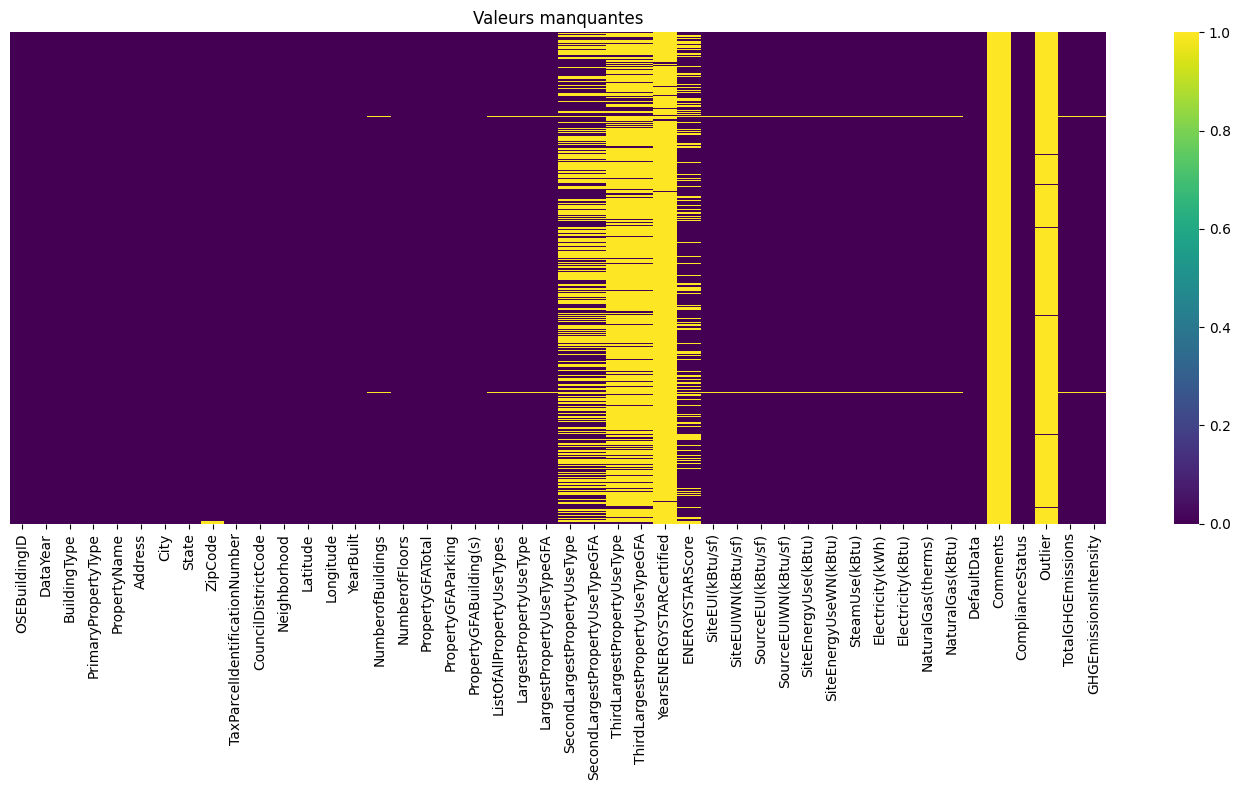

In [ ]:
plt.figure(figsize=(14, 8))
sns.heatmap(df.isnull(), yticklabels=False, cmap='viridis')
plt.title('Valeurs manquantes')
plt.tight_layout()
plt.show()

##  Distribution des variables cibles

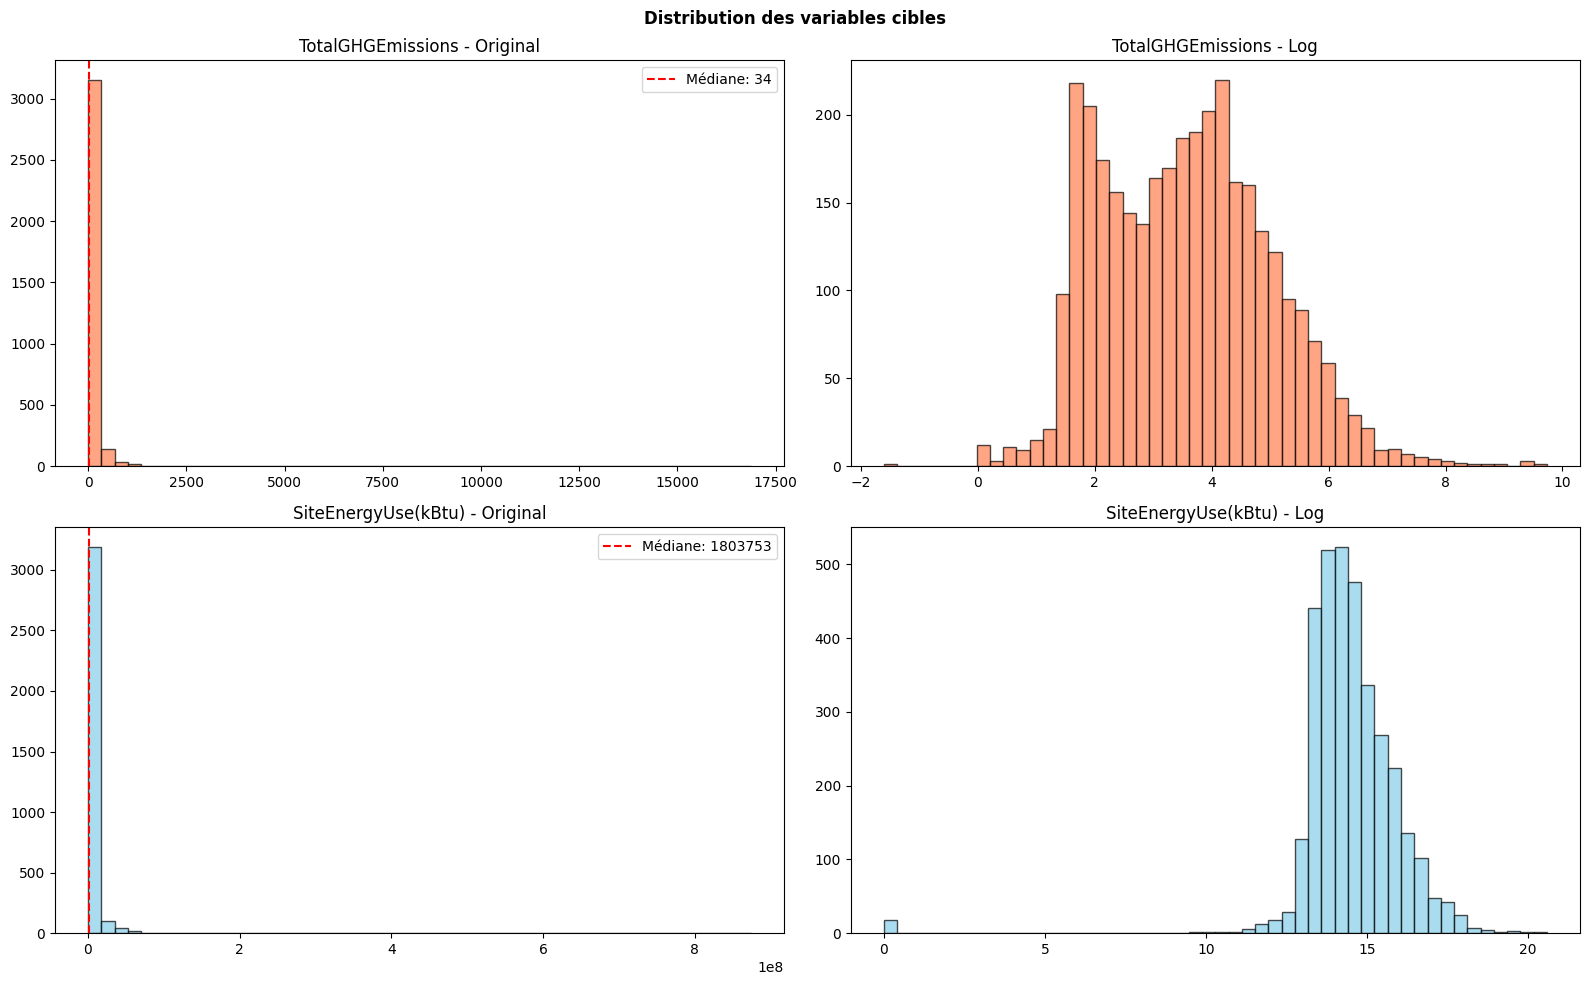

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

targets = ['TotalGHGEmissions', 'SiteEnergyUse(kBtu)']
colors = ['coral', 'skyblue']

for i, (target, color) in enumerate(zip(targets, colors)):
    data = df[target].dropna()

    # Distribution originale
    axes[i, 0].hist(data, bins=50, color=color,edgecolor='black', alpha=0.7)
    axes[i, 0].set_title(f'{target} - Original')
    axes[i, 0].axvline(data.median(), color='red', linestyle='--',
                       label=f'Médiane: {data.median():.0f}')
    axes[i, 0].legend()

    # Distribution log
    axes[i, 1].hist(np.log1p(data), bins=50,edgecolor='black', color=color, alpha=0.7)
    axes[i, 1].set_title(f'{target} - Log')

plt.suptitle('Distribution des variables cibles', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*60)
print("ANALYSE DE LA DISTRIBUTION")
print("="*60)

targets = ['TotalGHGEmissions', 'SiteEnergyUse(kBtu)']

for target in targets:
    data = df[target].dropna()
    skew = stats.skew(data)
    skew_log = stats.skew(np.log1p(data))

    print(f"\n{target}:")
    print(f"  Skewness: {skew:.2f}")
    print(f"  Skewness (log): {skew_log:.2f}")


ANALYSE DE LA DISTRIBUTION

TotalGHGEmissions:
  Skewness: 19.47
  Skewness (log): 0.33

SiteEnergyUse(kBtu):
  Skewness: 24.83
  Skewness (log): -3.86


##  Boxplots et détection des outliers

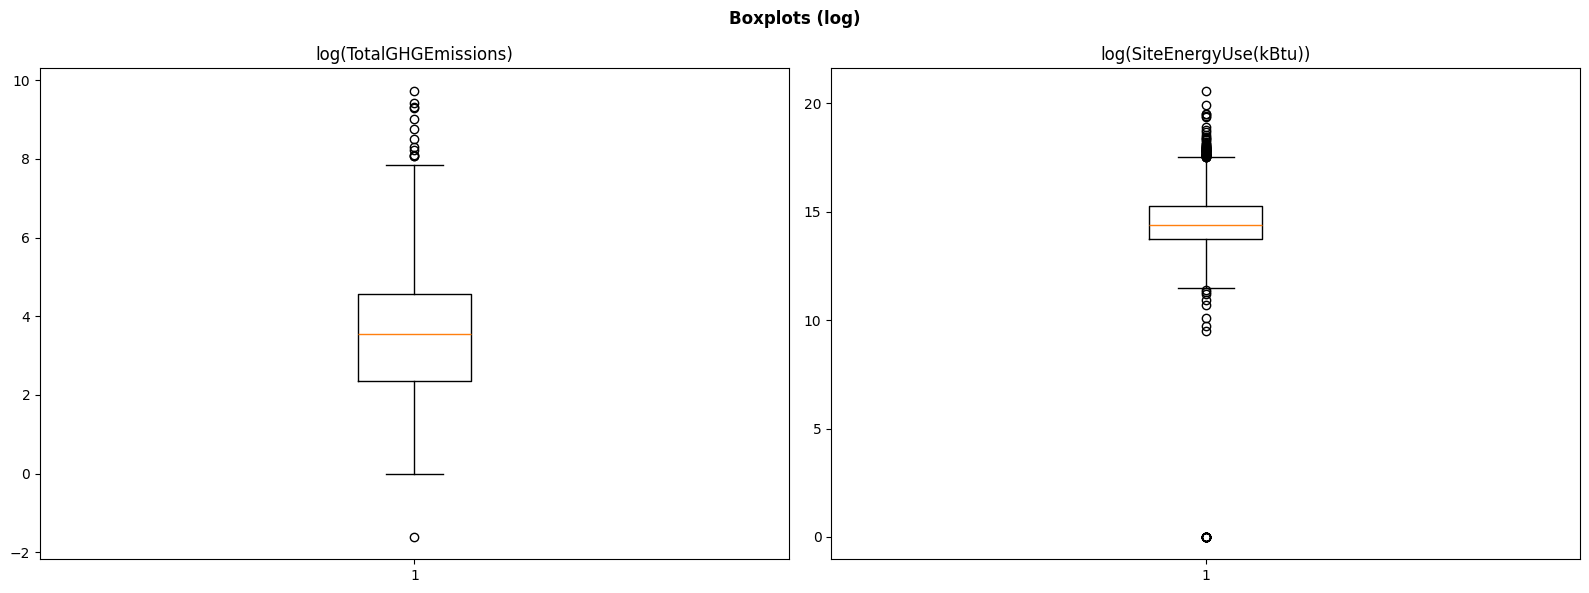

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

targets = ['TotalGHGEmissions', 'SiteEnergyUse(kBtu)']

for i, target in enumerate(targets):
    data = np.log1p(df[target].dropna())
    axes[i].boxplot(data)
    axes[i].set_title(f'log({target})')

plt.suptitle('Boxplots (log)', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("\nDÉTECTION DES OUTLIERS")
print("="*60)

targets = ['TotalGHGEmissions', 'SiteEnergyUse(kBtu)']

for target in targets:
    Q1 = df[target].quantile(0.25)
    Q3 = df[target].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[target] < Q1 - 1.5*IQR) | (df[target] > Q3 + 1.5*IQR)]

    print(f"\n{target}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")


DÉTECTION DES OUTLIERS

TotalGHGEmissions: 367 outliers (10.9%)

SiteEnergyUse(kBtu): 383 outliers (11.3%)


##  Corrélations avec les variables cibles

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

corr_ghg = df[numeric_cols].corr()['TotalGHGEmissions'].sort_values(ascending=False)
corr_energy = df[numeric_cols].corr()['SiteEnergyUse(kBtu)'].sort_values(ascending=False)

print("\nTotalGHGEmissions - Top 10:")
print(corr_ghg.head(10))

print("\nSiteEnergyUse(kBtu) - Top 10:")
print(corr_energy.head(10))


TotalGHGEmissions - Top 10:
TotalGHGEmissions                 1.000000
SiteEnergyUse(kBtu)               0.862668
SiteEnergyUseWN(kBtu)             0.859042
NaturalGas(therms)                0.732294
NaturalGas(kBtu)                  0.732294
Electricity(kWh)                  0.691111
Electricity(kBtu)                 0.691111
SteamUse(kBtu)                    0.683254
ThirdLargestPropertyUseTypeGFA    0.677722
LargestPropertyUseTypeGFA         0.578487
Name: TotalGHGEmissions, dtype: float64

SiteEnergyUse(kBtu) - Top 10:
SiteEnergyUse(kBtu)               1.000000
Electricity(kWh)                  0.956556
Electricity(kBtu)                 0.956556
TotalGHGEmissions                 0.862668
LargestPropertyUseTypeGFA         0.836185
PropertyGFABuilding(s)            0.811866
PropertyGFATotal                  0.796781
ThirdLargestPropertyUseTypeGFA    0.754093
SiteEnergyUseWN(kBtu)             0.715149
NumberofBuildings                 0.690712
Name: SiteEnergyUse(kBtu), dtype: float6

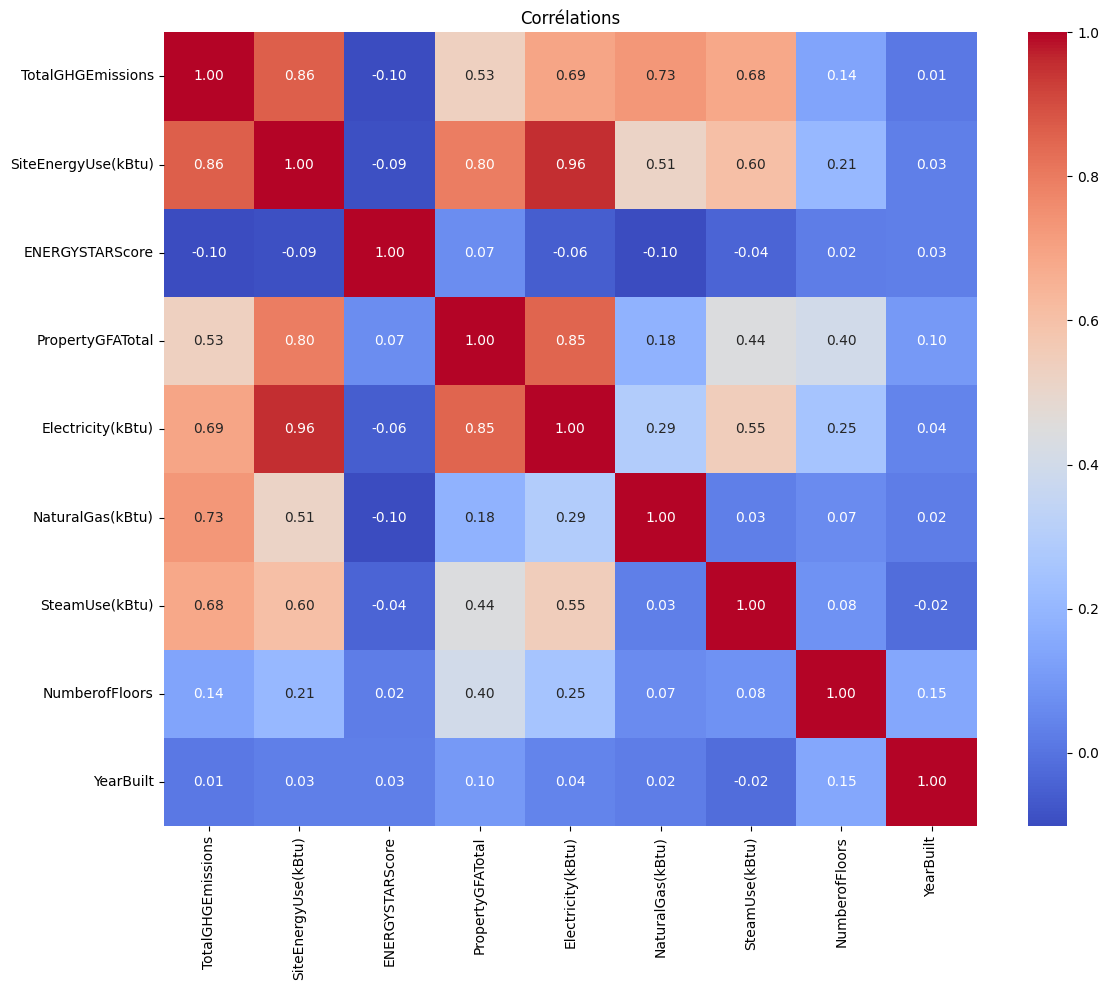

In [ ]:
features = ['TotalGHGEmissions', 'SiteEnergyUse(kBtu)', 'ENERGYSTARScore',
            'PropertyGFATotal', 'Electricity(kBtu)', 'NaturalGas(kBtu)',
            'SteamUse(kBtu)', 'NumberofFloors', 'YearBuilt']

plt.figure(figsize=(12, 10))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Corrélations')
plt.tight_layout()
plt.show()

##  Analyse des variables catégorielles

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

print(f"\n{len(categorical_cols)} variables catégorielles:")
print(list(categorical_cols))


15 variables catégorielles:
['BuildingType', 'PrimaryPropertyType', 'PropertyName', 'Address', 'City', 'State', 'TaxParcelIdentificationNumber', 'Neighborhood', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'YearsENERGYSTARCertified', 'ComplianceStatus', 'Outlier']


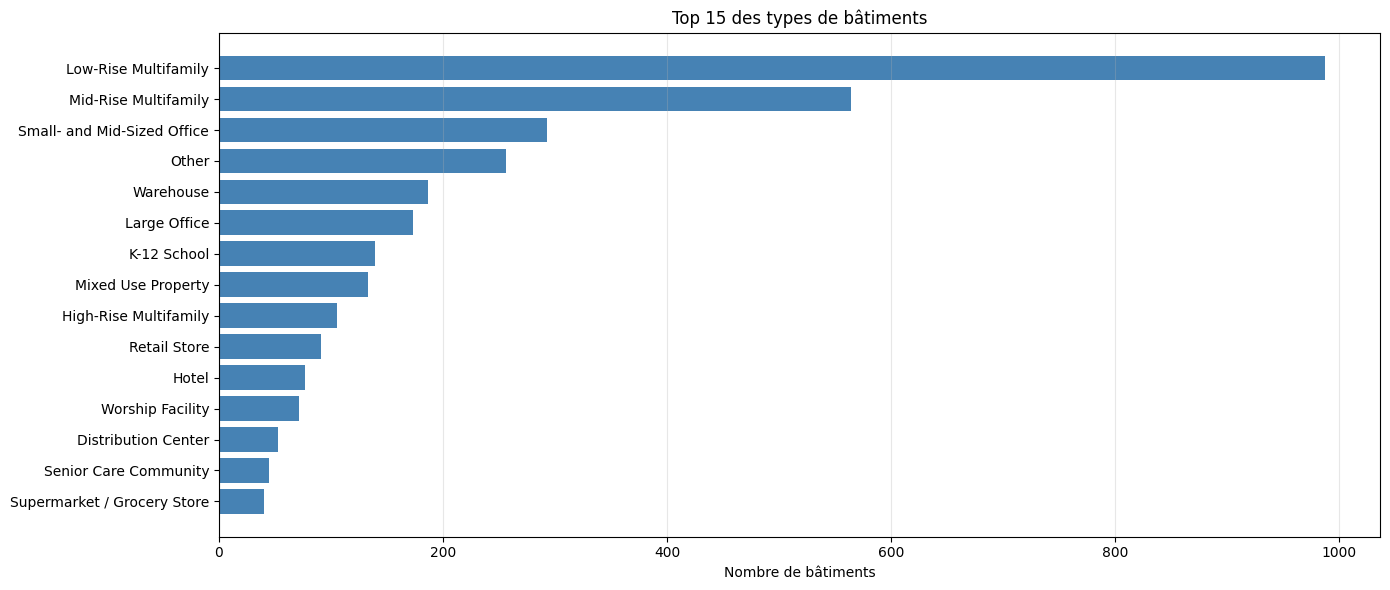


Distribution:
PrimaryPropertyType
Low-Rise Multifamily           987
Mid-Rise Multifamily           564
Small- and Mid-Sized Office    293
Other                          256
Warehouse                      187
Large Office                   173
K-12 School                    139
Mixed Use Property             133
High-Rise Multifamily          105
Retail Store                    91
Hotel                           77
Worship Facility                71
Distribution Center             53
Senior Care Community           45
Supermarket / Grocery Store     40
Name: count, dtype: int64


In [ ]:
if 'PrimaryPropertyType' in df.columns:
    property_counts = df['PrimaryPropertyType'].value_counts().head(15)

    plt.figure(figsize=(14, 6))
    plt.barh(property_counts.index, property_counts.values, color='steelblue')
    plt.xlabel('Nombre de bâtiments')
    plt.title('Top 15 des types de bâtiments')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nDistribution:")
    print(property_counts)

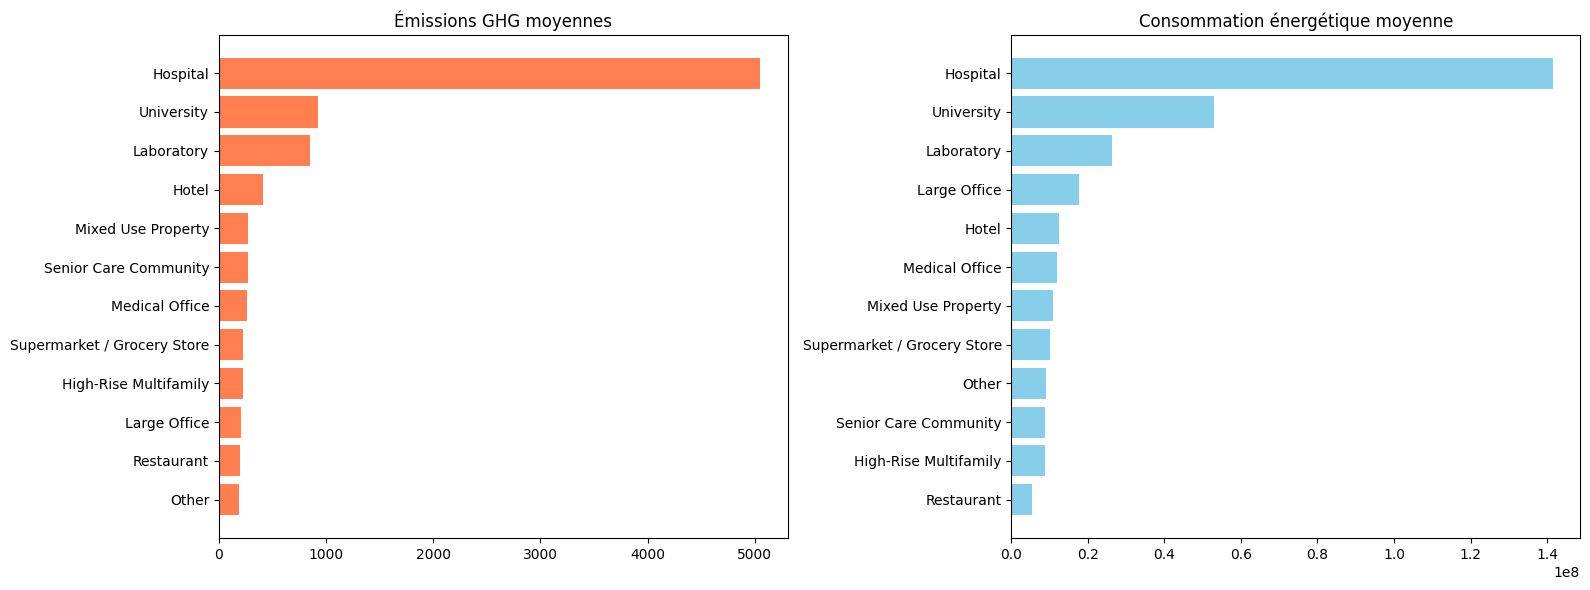

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GHG
ghg = df.groupby('PrimaryPropertyType')['TotalGHGEmissions'].mean().sort_values(ascending=False).head(12)
axes[0].barh(ghg.index, ghg.values, color='coral')
axes[0].set_title('Émissions GHG moyennes')
axes[0].invert_yaxis()

# Energy
energy = df.groupby('PrimaryPropertyType')['SiteEnergyUse(kBtu)'].mean().sort_values(ascending=False).head(12)
axes[1].barh(energy.index, energy.values, color='skyblue')
axes[1].set_title('Consommation énergétique moyenne')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

##  ENERGY STAR Score — Feature importante

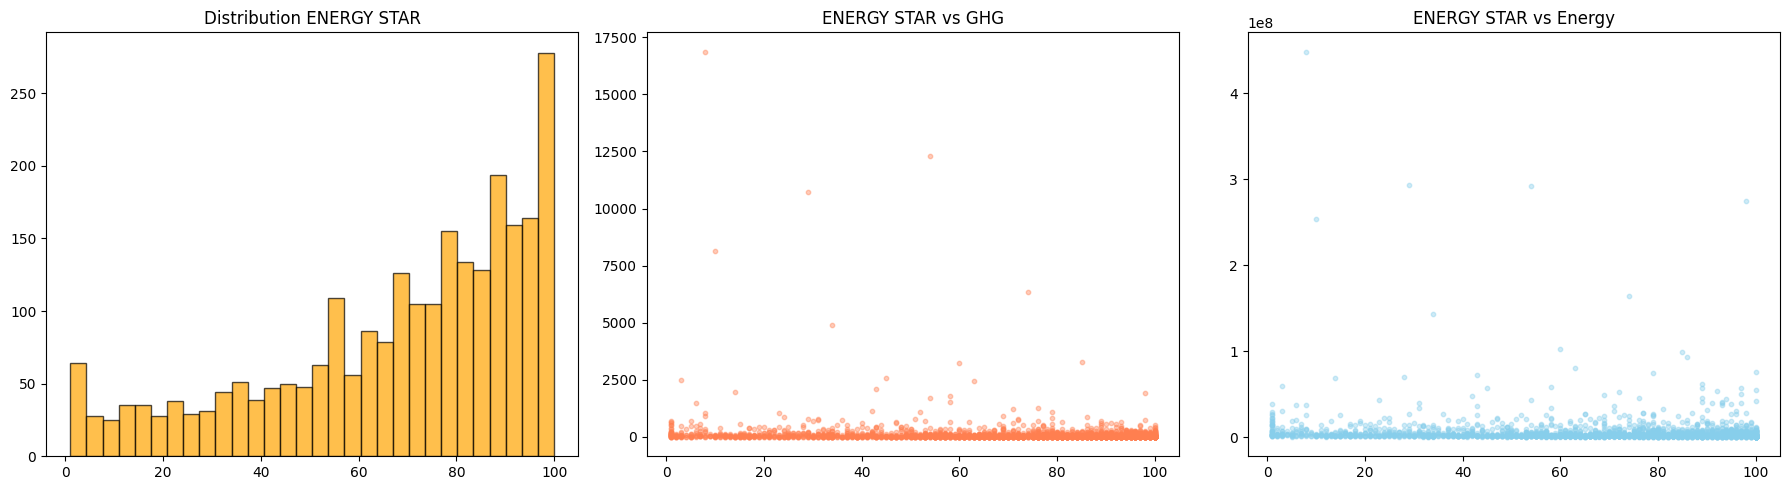

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['ENERGYSTARScore'].dropna(), bins=30, edgecolor='black', color='orange', alpha=0.7)
axes[0].set_title('Distribution ENERGY STAR')

axes[1].scatter(df['ENERGYSTARScore'], df['TotalGHGEmissions'], alpha=0.4, s=10, color='coral')
axes[1].set_title('ENERGY STAR vs GHG')

axes[2].scatter(df['ENERGYSTARScore'], df['SiteEnergyUse(kBtu)'], alpha=0.4, s=10, color='skyblue')
axes[2].set_title('ENERGY STAR vs Energy')

plt.tight_layout()
plt.show()

## Analyse géospatiale (Latitude/Longitude)

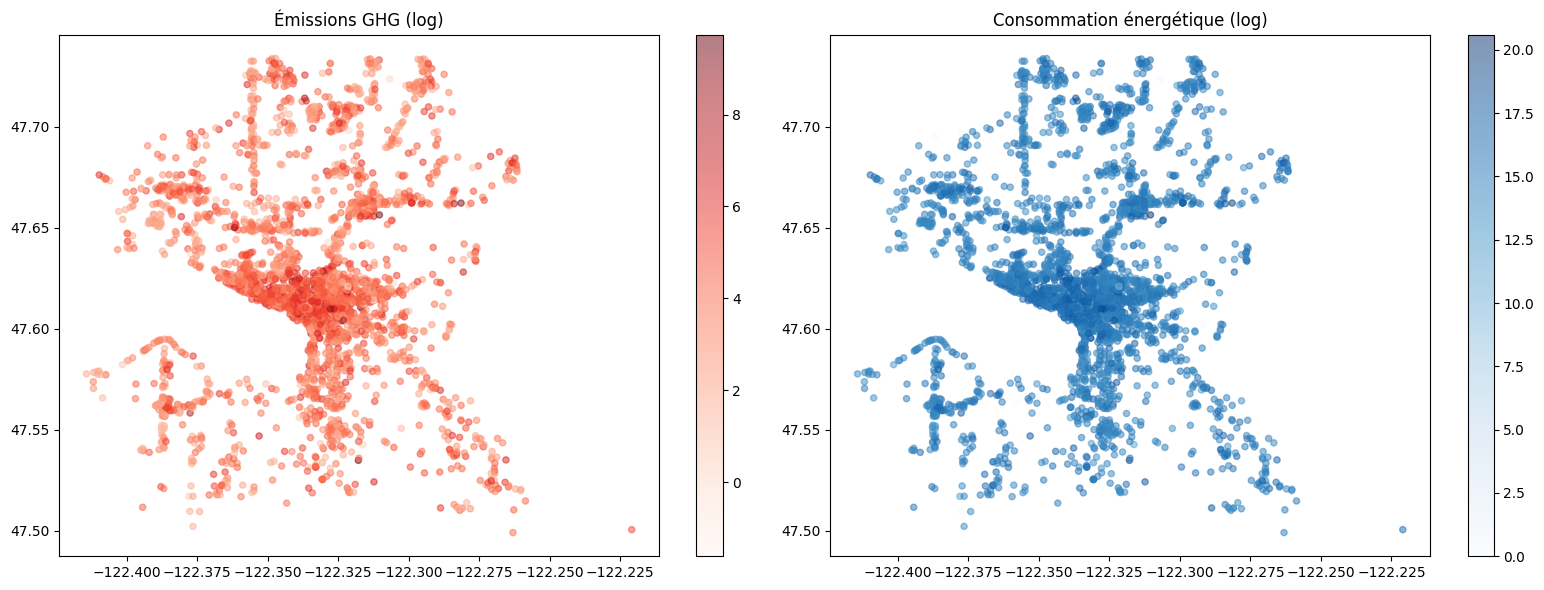

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GHG
scatter1 = axes[0].scatter(df['Longitude'], df['Latitude'],
                          c=np.log1p(df['TotalGHGEmissions']),
                          cmap='Reds', alpha=0.5, s=20)
axes[0].set_title('Émissions GHG (log)')
plt.colorbar(scatter1, ax=axes[0])

# Energy
scatter2 = axes[1].scatter(df['Longitude'], df['Latitude'],
                          c=np.log1p(df['SiteEnergyUse(kBtu)']),
                          cmap='Blues', alpha=0.5, s=20)
axes[1].set_title('Consommation énergétique (log)')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()